In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cafe.data import FateAnnData
import matplotlib.pyplot as plt
import seaborn as sns
#这里尝试仅调用一个接口计算聚合指标
from cafe.metric.calculate_metrics import calculate_metrics

[2025年10月15日 18时08分02秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据准备

In [2]:
fadata = cafe.data.read_erythroid_lineage(n_obs=500)#用于快速测试
fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 500 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

绘图

                        DEBUG    plot_trajectory                                                                   
[2025年10月15日 18时08分03秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (206, 500), finished!                                      
                        DEBUG    plot_trajectory                                                                   
[2025年10月15日 18时08分04秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (206, 500), finished!                                      


AnnData object with n_obs × n_vars = 500 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

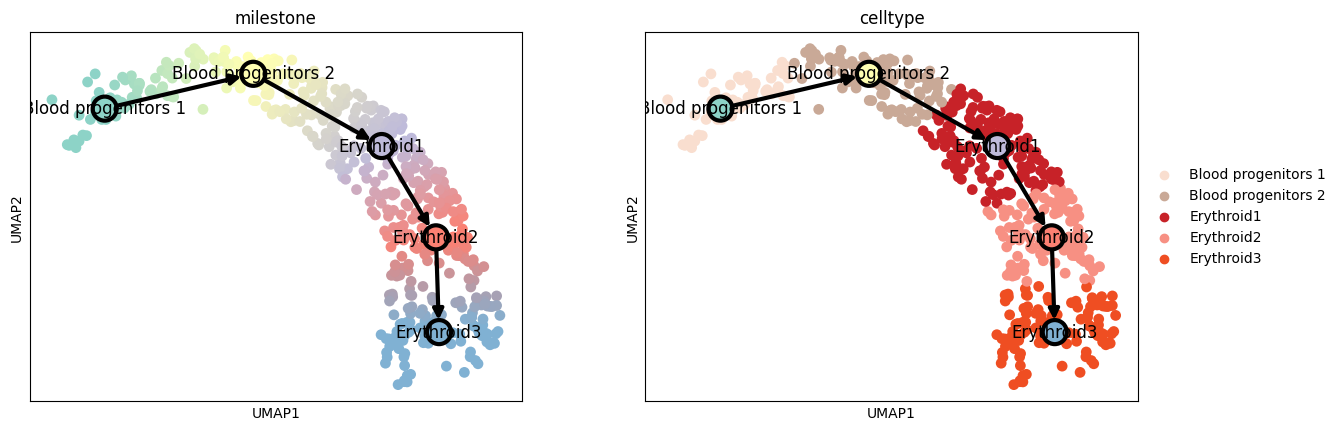

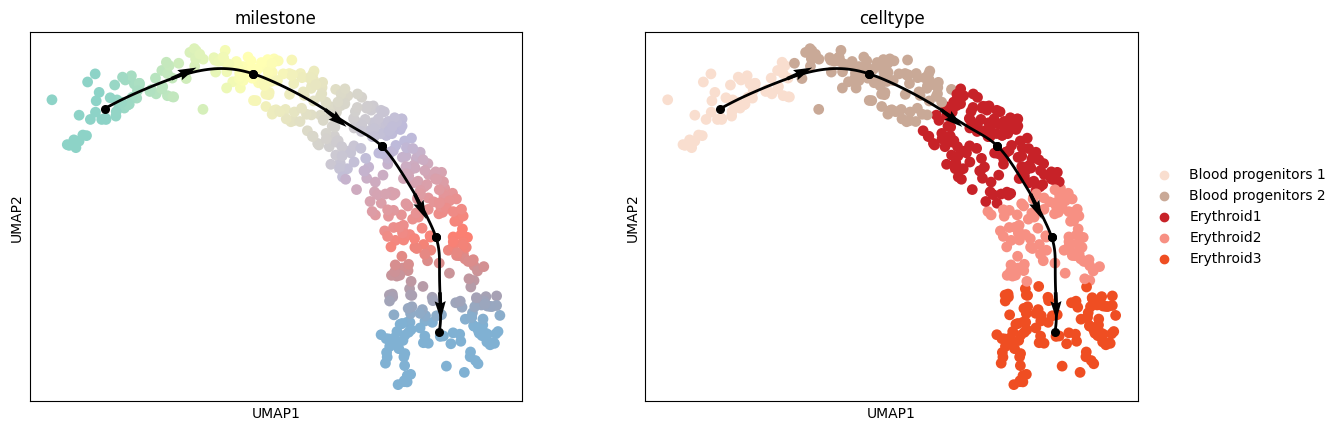

In [3]:
cluster_key = "celltype"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年10月15日 18时08分07秒] INFO     find wrapper type: directed                                                 


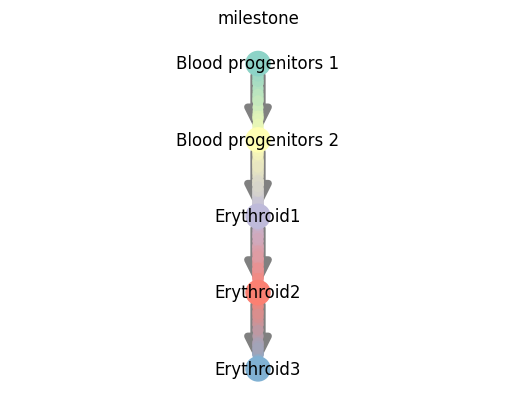

In [4]:
cafe.plot.plot_wrapper(fadata)

添加先验，封装轨迹结构并绘图

[2025年10月15日 18时08分09秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x769f21bf1cf0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x769f3a9a8fd0>                                                                   
                        DEBUG    Add trajectory by wrapper type: linear                                            
                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                             

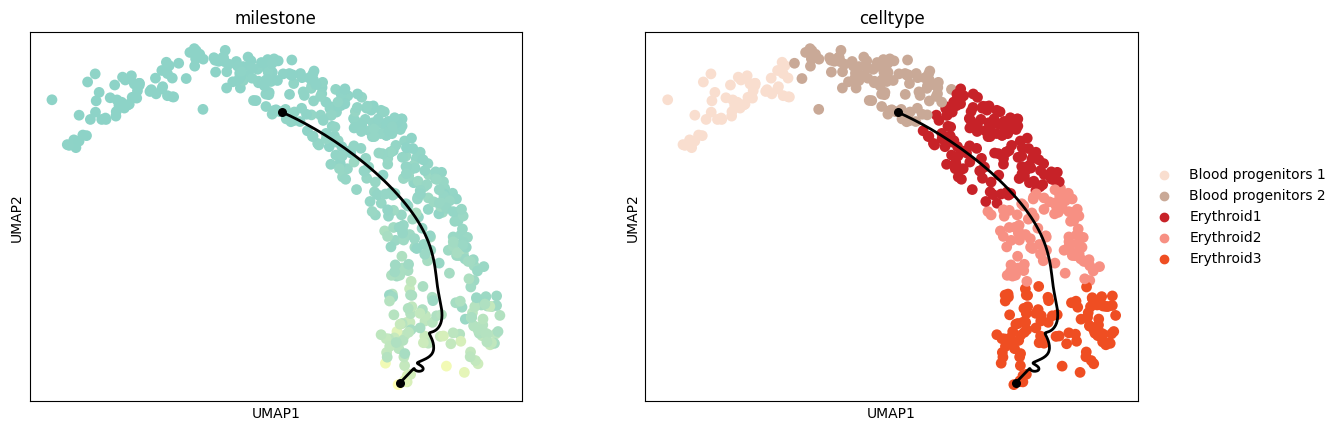

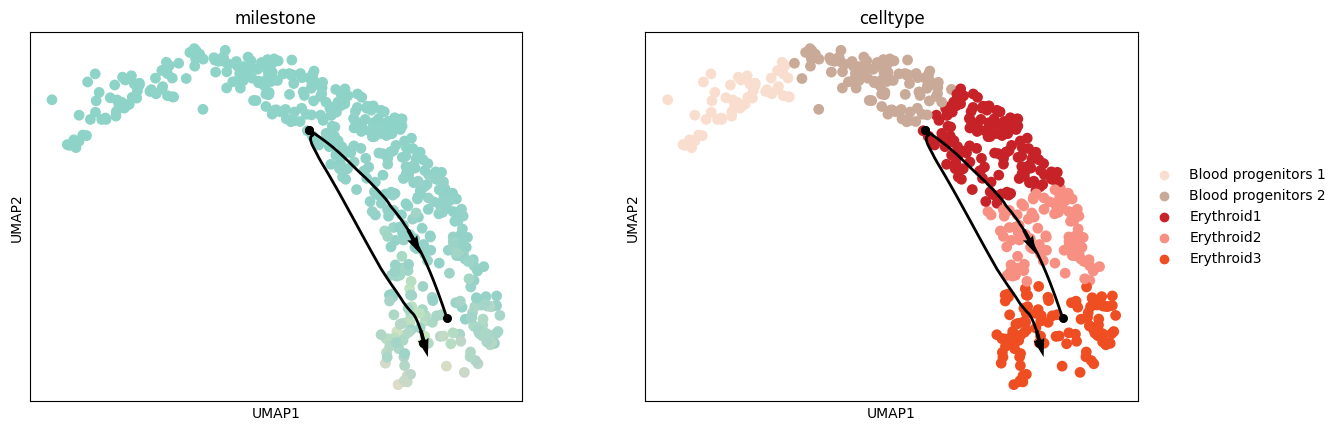

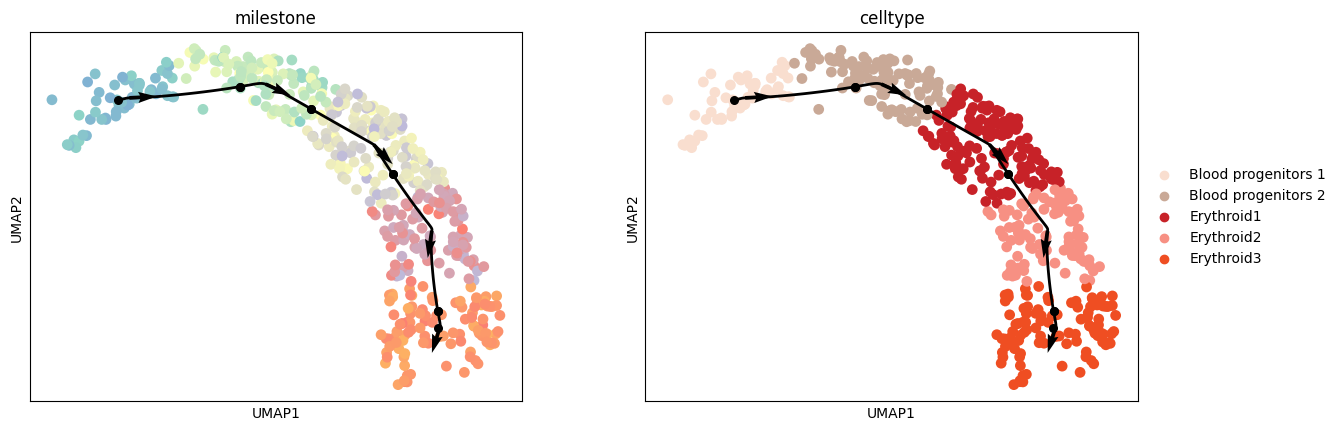

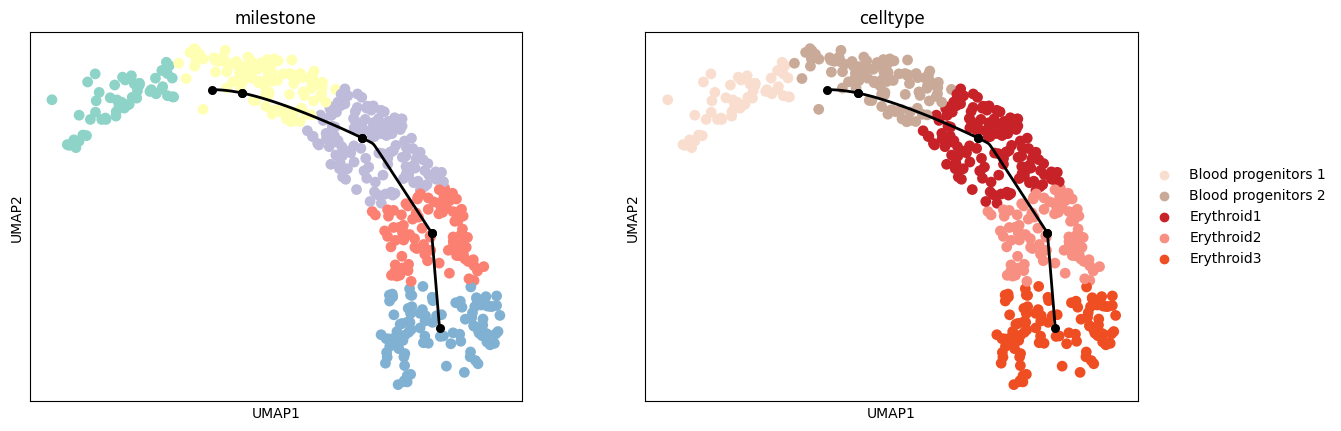

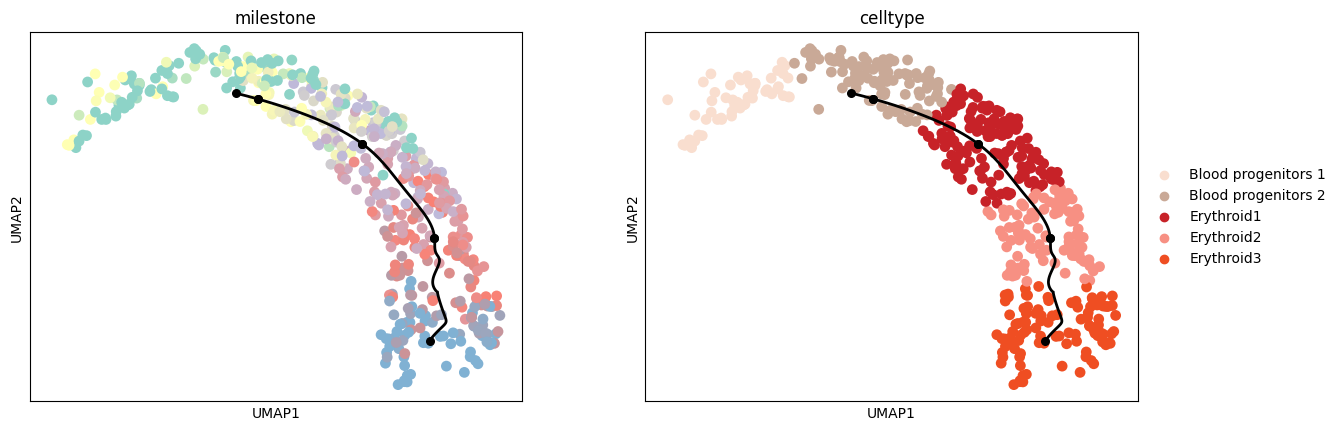

In [5]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]

for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年10月15日 18时08分26秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'paga-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function'],
 ['ref',
  '20251015_180809__comp1-python_function__VkRf8DUDV6',
  '20251015_180811__state_comp-python_function__lxfxTlDAZ6',
  '20251015_180812__paga-python_function__j8jjKz389F',
  '20251015_180817__cluster_mst-python_function__7JUU8VlkWC',
  '20251015_180818__projection_mst-python_function__ps4QM2McBV'])

In [7]:
#这里需要构造新的fadata与计算接口兼容，原生fadata嵌套结构与接口不兼容
new_fadata=cafe.data.FateAnnData(X=fadata.X, obs=fadata.obs, uns=fadata.uns)
#除此之外还要为新的fadata添加必要的属性，与旧的fadata保持一致
for i in model_name_list:
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]["milestone_wrapper"]
    new_fadata.add_waypoints()
    # 使用单引号避免冲突
    print(f"{i}'s milestone_network is:\n {new_fadata.milestone_wrapper['milestone_network']}")
    print(f"{i}'s progressions is:\n {new_fadata.milestone_wrapper['progressions']}")


prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

                        DEBUG    FateAnnData add_waypoints                                                         
ref's milestone_network is:
                   from                   to    length  directed
0  Blood progenitors 1  Blood progenitors 2  3.674858      True
1  Blood progenitors 2           Erythroid1  4.007710      True
2           Erythroid1           Erythroid2  3.113946      True
3           Erythroid2           Erythroid3  2.664817      True
ref's progressions is:
             cell_id                 from                   to  percentage
0    GAGTGGGACTGAGT  Blood progenitors 1  Blood progenitors 2    0.583404
1    GGACCGTGGAAAGT  Blood progenitors 2           Erythroid1    0.244262
2    ATCAAATGTTCTGT  Blood progenitors 2           Erythroid1    0.062283
3    GCGGCAACGGTGTT  Blood progenitors 2           Erythroid1    0.295279
4    GCGTAATGCGTACA  Blood progenitors 2           Erythroid1    0.161260
..              ...                  ...                  ...      

测试新接口

In [8]:
new_fadata

AnnData object with n_obs × n_vars = 500 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors'

In [9]:
new_fadata.uns

{'celltype_colors': array(['#f9decf', '#c9a997', '#C72228', '#f79083', '#EF4E22'],
       dtype=object),
 'cfe': {'prior_information': {'start_id': 'GAGTGGGACTGAGT',
   'groups_id': ['Blood progenitors 2',
    'Erythroid1',
    'Erythroid2',
    'Erythroid1',
    'Blood progenitors 1',
    'Erythroid3',
    'Erythroid2',
    'Erythroid3',
    'Erythroid3',
    'Erythroid3',
    'Blood progenitors 2',
    'Blood progenitors 2',
    'Blood progenitors 2',
    'Erythroid2',
    'Erythroid3',
    'Blood progenitors 2',
    'Erythroid2',
    'Erythroid2',
    'Blood progenitors 2',
    'Erythroid2',
    'Erythroid1',
    'Erythroid3',
    'Blood progenitors 2',
    'Erythroid2',
    'Blood progenitors 2',
    'Erythroid2',
    'Erythroid1',
    'Erythroid3',
    'Erythroid1',
    'Blood progenitors 2',
    'Erythroid1',
    'Erythroid1',
    'Blood progenitors 2',
    'Erythroid2',
    'Erythroid3',
    'Erythroid1',
    'Blood progenitors 2',
    'Blood progenitors 1',
    'Erythroid1',
  

In [10]:
hist=fadata.uns.get("cfe", {}).get("trajectory_history_dict", {})
hist

{'ref': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x769f3e9fef20>,
  'raw_wrapper_dict': {},
  'trajectory_embedding': {},
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x769f3e9ff100>},
 '20251015_180809__comp1-python_function__VkRf8DUDV6': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x769f3bb10940>,
  'raw_wrapper_dict': {},
  'trajectory_embedding': {},
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x769f20aaa5f0>},
 '20251015_180811__state_comp-python_function__lxfxTlDAZ6': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x769f3f1c4610>,
  'raw_wrapper_dict': {'pseudotime': array([-6.13563049e+02, -5.30003052e+02, -1.60166733e+02, -4.30953186e+02,
          -6.17416077e+02,  1.45673975e+03,  2.83803040e+02,  1.92119958e+03,
           1.12515332e+03,  5.55581787e+02, -3.89523743e+02, -5.59710938e+02,
          -5.71004761e+02,  3.6351

In [11]:
list(hist.keys())

['ref',
 '20251015_180809__comp1-python_function__VkRf8DUDV6',
 '20251015_180811__state_comp-python_function__lxfxTlDAZ6',
 '20251015_180812__paga-python_function__j8jjKz389F',
 '20251015_180817__cluster_mst-python_function__7JUU8VlkWC',
 '20251015_180818__projection_mst-python_function__ps4QM2McBV']

In [12]:
calculate_metrics(new_fadata, now_model=model_name_list, ref_model="ref")

,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,featureimp_cor,featureimp_wcor
ref,1.0,1.0,1.000000,1.000000,1.000000,1.000000,0.000035,0.999671,0.999648,1.000000,0.000000,1.000000,1.000000,1.000000
20251015_180809__comp1-python_function__VkRf8DUDV6,1.0,1.0,1.000000,0.000000,0.278369,0.225354,0.054057,0.484963,0.467945,0.257251,0.077957,0.213302,0.836558,0.878297
20251015_180811__state_comp-python_function__lxfxTlDAZ6,0.0,0.0,0.739605,0.000000,0.322428,0.161261,0.044679,0.574312,0.555807,0.267157,0.076917,0.226509,0.858895,0.898227
20251015_180812__paga-python_function__j8jjKz389F,1.0,1.0,1.000000,0.156508,0.515366,0.439208,0.021632,0.793893,0.794468,0.696118,0.031895,0.690206,0.974757,0.984719
20251015_180817__cluster_mst-python_function__7JUU8VlkWC,1.0,1.0,1.000000,0.406202,0.548617,1.000000,0.011857,0.887034,0.884050,0.887540,0.011804,0.884555,0.978316,0.987465
20251015_180818__projection_mst-python_function__ps4QM2McBV,1.0,1.0,1.000000,0.335360,0.618677,0.459466,0.050920,0.514850,0.483029,0.567114,0.045435,0.535546,0.936203,0.955543
